# Object Detection — Stage 1 (Localisation & Multi-Object Detection)

Trains `ObjectDetectorResNet` to predict up to `MAX_OBJECTS` bounding boxes per image.
Each predicted slot is `[x, y, w, h, conf]`; confidence is a raw logit trained with BCE.

**Pipeline:**  
`get_detection_loaders` → `ObjectDetectorResNet` → `DetectionLoss` → `fit()`


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch

from utils.dataset import get_detection_loaders, S
from generator.dataset import EMNIST_CLASS_NAMES
from utils.trainer import fit, evaluate_detection, evaluate_detection_sweep
from utils.visualizer import Visualizer
from utils.callbacks import ModelCheckpoint
from utils.losses import DetectionLoss
from models import get_detector

# ── Config ────────────────────────────────────────────────────────────────────
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT_DIR    = '../data'
BATCH_SIZE  = 128
EPOCHS      = 60
GRID_SIZE   = S        # 14x14 grid
CONF_THRESH = 0.5     # sigmoid threshold at inference
MODEL_SIZE  = 'm'
CLASS_NAMES = EMNIST_CLASS_NAMES['bymerge']

print(f'Device   : {DEVICE}')
print(f'PyTorch  : {torch.__version__}')
print(f'Grid Size: {GRID_SIZE}x{GRID_SIZE}')


Device   : cuda
PyTorch  : 2.11.0+cu130
Grid Size: 14x14


## 1 · Data Loaders


In [2]:
train_loader, val_loader, test_loader = get_detection_loaders(
    batch_size = BATCH_SIZE,
    test=True,
)

# ── Sanity check ──────────────────────────────────────────────────────────────
batch = next(iter(train_loader))
imgs, targets, labels = batch

print(f'Image batch shape : {imgs.shape}')
print(f'GT grid targets   : {targets.shape}')  # (B, S, S, 5)
print(f'GT grid labels    : {labels.shape}')   # (B, S, S)
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')


Image batch shape : torch.Size([128, 1, 224, 224])
GT grid targets   : torch.Size([128, 14, 14, 5])
GT grid labels    : torch.Size([128, 14, 14])
Train batches: 1875 | Val batches: 118


## 2 · Model


In [3]:
model = get_detector(size=MODEL_SIZE).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

# ── Forward smoke-test ────────────────────────────────────────────────────────
with torch.no_grad():
    out = model(imgs.to(DEVICE))
print(f'Output shape: {out.shape}')  # (B, S, S, 5 + num_classes)


Parameters: 6,178,996
Output shape: torch.Size([128, 14, 14, 52])


## 4 · Optimiser & Scheduler


In [4]:
criterion = DetectionLoss(
    lambda_conf    = 1.0,
    lambda_class   = 1.0,
    lambda_iou     = 1.0,
    use_pos_weight = True,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = 1e-3,
    weight_decay = 1e-4,
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr          = 1e-3,
    steps_per_epoch = len(train_loader),
    epochs          = EPOCHS,
)

NAME = f"grid_detector_{MODEL_SIZE}"
checkpoint = ModelCheckpoint(
    model, verbose=False,
    checkpoint_path=f"../checkpoint/{NAME}_latest.pth",
    best_model_path=f"../checkpoint/{NAME}_best.pth",
    mode='max'   # maximise val_f1
)

scaler = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None

print(f'Criterion : {type(criterion).__name__}')
print(f'Optimizer : {type(optimizer).__name__}')
print(f'Scheduler : {type(scheduler).__name__}')


Criterion : DetectionLoss
Optimizer : AdamW
Scheduler : OneCycleLR


## 5 · Train


In [5]:
history, logger = fit(
    model       = model,
    trainloader = train_loader,
    valloader   = val_loader,
    criterion   = criterion,
    optimizer   = optimizer,
    device      = DEVICE,
    epochs      = EPOCHS,
    scheduler   = scheduler,
    scaler      = scaler,
    checkpoint  = checkpoint,
    step_scheduler_per_batch = True,
    verbose     = True,
    log         = True,
    model_label = NAME,
    resume      = True,
)


Training with bf16 autocast | Epochs: 60
[RunLogger] ▶  Run 'grid_detector_m_20260810_100234' started — saving to 'C:\OD-From-Scratch\logs\ObjectDetectorResNet\grid_detector_m_20260810_100234.json'
Resuming training from epoch 6
Batch  1 | data=382.5ms pad=0.8ms forward=173.3ms loss=228.9ms backward=321.1ms step=125.8ms
Batch  2 | data=0.2ms pad=0.5ms forward=21.9ms loss=2.4ms backward=47.7ms step=4.4ms
Batch  3 | data=0.1ms pad=0.5ms forward=22.0ms loss=2.3ms backward=46.7ms step=2.4ms
Batch  4 | data=0.2ms pad=0.5ms forward=21.8ms loss=2.0ms backward=46.6ms step=3.8ms
Batch  5 | data=0.2ms pad=0.5ms forward=23.0ms loss=2.7ms backward=46.2ms step=4.5ms
Train: 144.9s | Val: 44.1s
  --> Det  | PR: 0.648 | Rec: 0.718 | F1: 0.681 | TP: 86055 FP: 46765 FN: 33850
  --> Cls  | Acc: 0.855
  --> E2E  | F1: 0.583 | PR: 0.554 | Rec: 0.614
[RunLogger] Epoch   7 | train_loss=3.8267  val_loss=4.0426  val_f1=0.6810%  lr=3.56e-04  ⏱ 144.9s  ★ NEW BEST
Batch  1 | data=455.8ms pad=0.7ms forward=22.6ms 

## 6 · Training Curves


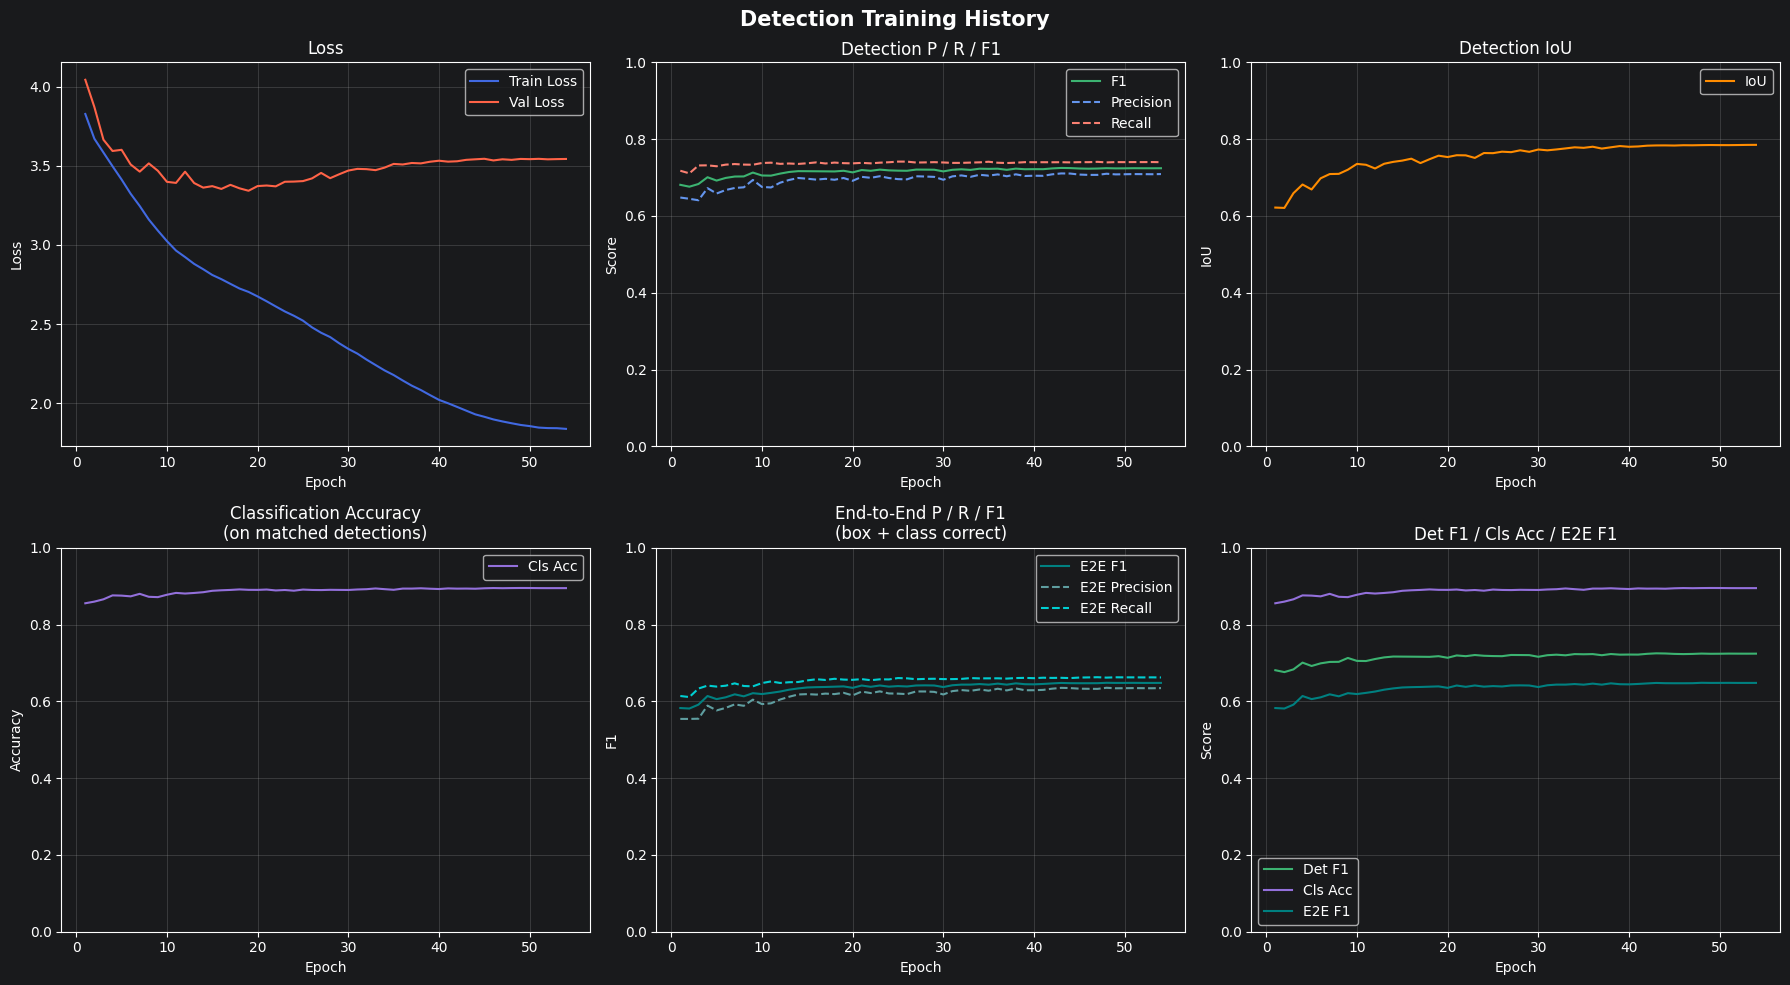

In [6]:
# Full detection training dashboard (Loss, Det P/R/F1, IoU, Cls Acc, E2E P/R/F1)
Visualizer.visualize_detection_history(history)


## 7 · Final Evaluation on Test Set


In [7]:
# Load best checkpoint weights if checkpoint callback was used
if 'checkpoint' in locals() and checkpoint is not None:
    checkpoint.restore_best_weights()

metrics = evaluate_detection(model, test_loader, criterion, DEVICE, conf_threshold=CONF_THRESH)

det = metrics['detection']
cls = metrics['classification']
e2e = metrics['end_to_end']

print('=== Detection (localisation) ===')
print(f"  Loss     : {metrics['loss']:.4f}")
print(f"  IoU      : {det['iou']:.4f}")
print(f"  Precision: {det['precision']:.4f}")
print(f"  Recall   : {det['recall']:.4f}")
print(f"  F1       : {det['f1']:.4f}")
print(f"  TP/FP/FN : {det['tp']} / {det['fp']} / {det['fn']}")

print('\n=== Classification (on matched detections) ===')
print(f"  Accuracy : {cls['accuracy']:.4f}")
print('  Per-class:')
for k, v in cls['per_class'].items():
    name = v.get('name', f'class_{k}')
    print(f"    [{k}] {name}: acc={v['accuracy']:.4f}  "
          f"e2e_p={v['e2e_precision']:.4f}  e2e_r={v['e2e_recall']:.4f}  e2e_f1={v['e2e_f1']:.4f}")

print('\n=== End-to-End (box + class correct) ===')
print(f"  Precision: {e2e['precision']:.4f}")
print(f"  Recall   : {e2e['recall']:.4f}")
print(f"  F1       : {e2e['f1']:.4f}")
print(f"  TP/FP/FN : {e2e['tp']} / {e2e['fp']} / {e2e['fn']}")


=== Detection (localisation) ===
  Loss     : 3.5461
  IoU      : 0.7849
  Precision: 0.7147
  Recall   : 0.7435
  F1       : 0.7288
  TP/FP/FN : 268082 / 107025 / 92485

=== Classification (on matched detections) ===
  Accuracy : 0.8836
  Per-class:
    [0] class_0: acc=0.7153  e2e_p=0.5057  e2e_r=0.5655  e2e_f1=0.5339
    [1] class_1: acc=0.6831  e2e_p=0.4056  e2e_r=0.5205  e2e_f1=0.4559
    [2] class_2: acc=0.9148  e2e_p=0.6876  e2e_r=0.7241  e2e_f1=0.7054
    [3] class_3: acc=0.9728  e2e_p=0.7308  e2e_r=0.7639  e2e_f1=0.7470
    [4] class_4: acc=0.9366  e2e_p=0.7164  e2e_r=0.7375  e2e_f1=0.7268
    [5] class_5: acc=0.9010  e2e_p=0.7109  e2e_r=0.7124  e2e_f1=0.7117
    [6] class_6: acc=0.9295  e2e_p=0.7052  e2e_r=0.7295  e2e_f1=0.7171
    [7] class_7: acc=0.9743  e2e_p=0.7125  e2e_r=0.7610  e2e_f1=0.7359
    [8] class_8: acc=0.9592  e2e_p=0.7095  e2e_r=0.7474  e2e_f1=0.7279
    [9] class_9: acc=0.7773  e2e_p=0.5422  e2e_r=0.6057  e2e_f1=0.5722
    [10] class_10: acc=0.9718  e2e_p=0.

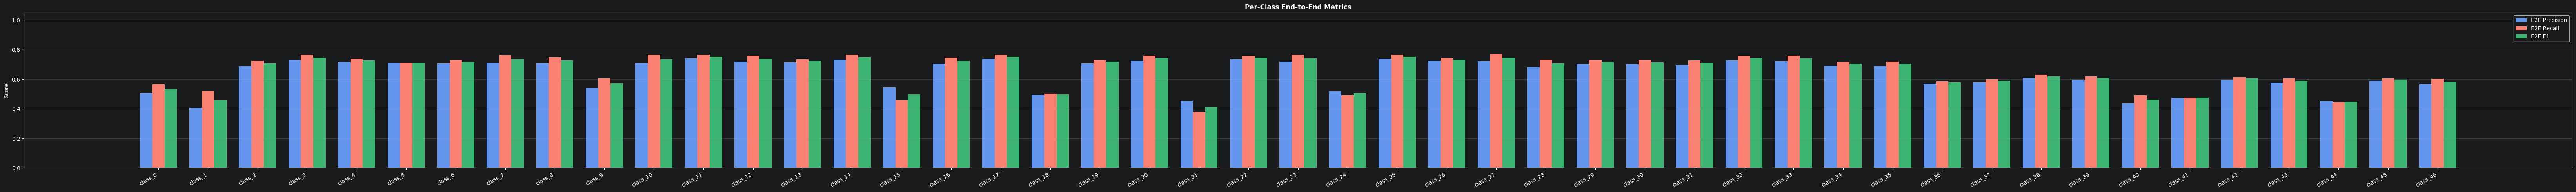

In [8]:
Visualizer.visualize_per_class_e2e(metrics)

## 8 · Prediction Visualisation

- **Lime** boxes = ground truth
- **Red** (dashed) boxes = model predictions with `conf > CONF_THRESH`


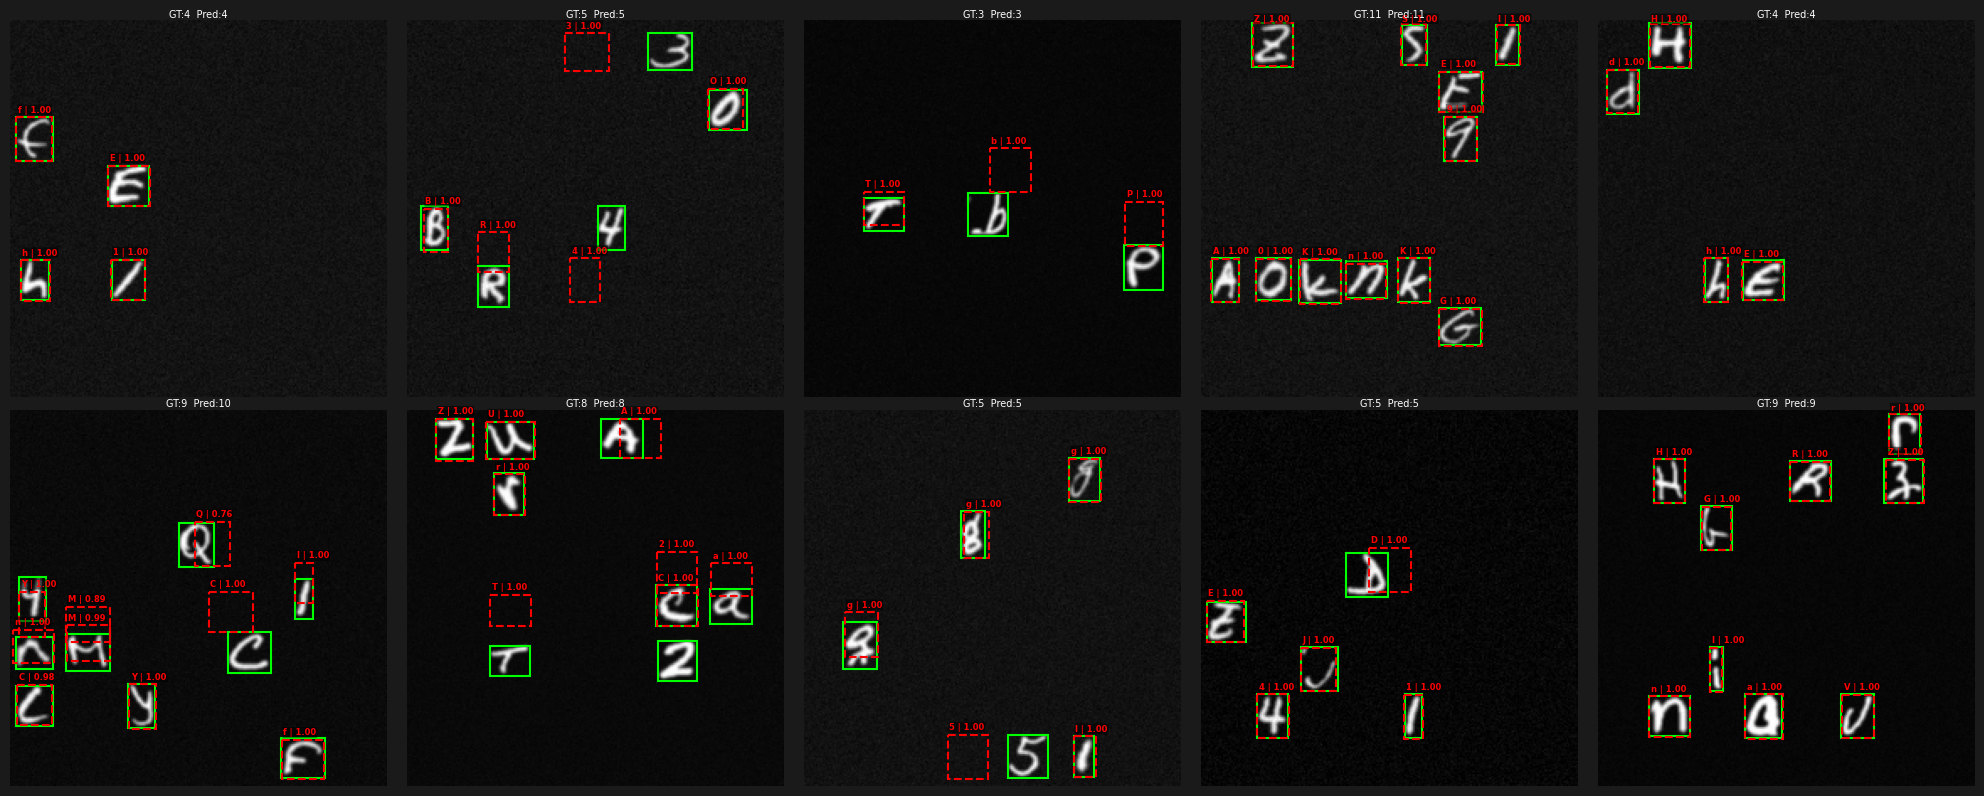

In [9]:
test_batch = next(iter(test_loader))
imgs_t, targets_t, labels_t = test_batch
with torch.no_grad():
    preds_t = model(imgs_t.to(DEVICE)).cpu()

Visualizer.visualize_multi_detection_batch(
    imgs_v=imgs_t,
    preds=preds_t,
    gt_grid=targets_t,
    conf_thresh=CONF_THRESH,
    class_names=CLASS_NAMES,
)


## 9 · Confidence Threshold Sweep

Sweeps confidence thresholds on the held-out **test set** to see the full P/R/F1 trade-off.


In [10]:
sweep_results = evaluate_detection_sweep(
    model, test_loader, DEVICE,
    conf_thresholds=np.arange(0.1, 0.95, 0.05),
    iou_threshold=0.5,
    print_table=True,
)

if 'logger' in locals() and logger is not None:
    logger.log_test_results(sweep_results, iou_threshold=0.5)



  Conf       P       R      F1   ClsAcc       TP       FP       FN
------------------------------------------------------------------
  0.10  0.6834  0.7496  0.7150   0.8828   270270   125194    90297
  0.15  0.6906  0.7483  0.7183   0.8830   269816   120866    90751
  0.20  0.6958  0.7473  0.7206   0.8832   269458   117812    91109
  0.25  0.7000  0.7465  0.7225   0.8832   269148   115363    91419
  0.30  0.7034  0.7458  0.7240   0.8833   268902   113367    91665
  0.35  0.7065  0.7451  0.7253   0.8834   268659   111603    91908
  0.40  0.7094  0.7445  0.7266   0.8835   268452   109948    92115
  0.45  0.7121  0.7440  0.7277   0.8836   268260   108442    92307
  0.50  0.7147  0.7435  0.7288   0.8836   268082   107025    92485
  0.55  0.7172  0.7430  0.7298   0.8837   267890   105656    92677
  0.60  0.7194  0.7425  0.7308   0.8837   267731   104442    92836
  0.65  0.7217  0.7421  0.7318   0.8838   267591   103194    92976
  0.70  0.7240  0.7417  0.7327   0.8838   267433   101947    

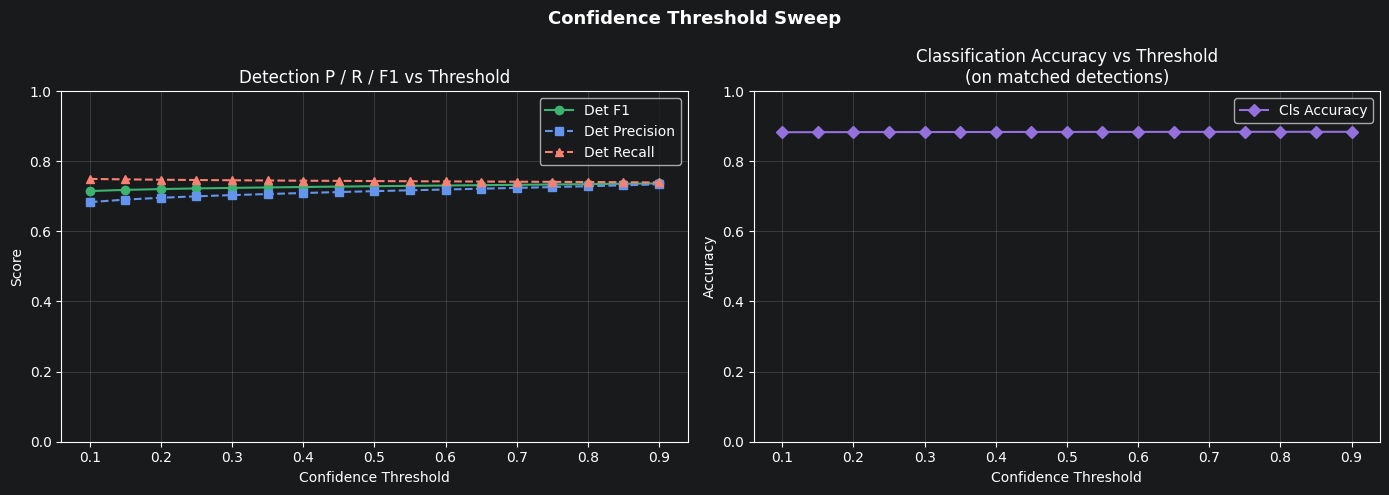


Best conf threshold : 0.90
  Det  F1  = 0.7369
  Cls  Acc = 0.8840
Per-class E2E F1:
  [0] class_0: e2e_f1=0.5381  e2e_p=0.5151  e2e_r=0.5634
  [1] class_1: e2e_f1=0.4633  e2e_p=0.4186  e2e_r=0.5186
  [2] class_2: e2e_f1=0.7153  e2e_p=0.7099  e2e_r=0.7208
  [3] class_3: e2e_f1=0.7556  e2e_p=0.7511  e2e_r=0.7601
  [4] class_4: e2e_f1=0.7344  e2e_p=0.7350  e2e_r=0.7338
  [5] class_5: e2e_f1=0.7188  e2e_p=0.7286  e2e_r=0.7093
  [6] class_6: e2e_f1=0.7239  e2e_p=0.7231  e2e_r=0.7247
  [7] class_7: e2e_f1=0.7469  e2e_p=0.7356  e2e_r=0.7585
  [8] class_8: e2e_f1=0.7355  e2e_p=0.7264  e2e_r=0.7447
  [9] class_9: e2e_f1=0.5785  e2e_p=0.5570  e2e_r=0.6018
  [10] class_10: e2e_f1=0.7454  e2e_p=0.7292  e2e_r=0.7624
  [11] class_11: e2e_f1=0.7584  e2e_p=0.7571  e2e_r=0.7598
  [12] class_12: e2e_f1=0.7478  e2e_p=0.7388  e2e_r=0.7569
  [13] class_13: e2e_f1=0.7325  e2e_p=0.7327  e2e_r=0.7323
  [14] class_14: e2e_f1=0.7569  e2e_p=0.7543  e2e_r=0.7595
  [15] class_15: e2e_f1=0.5020  e2e_p=0.5584  e2e

In [11]:
# Plot Det P/R/F1 and Cls Accuracy across thresholds
Visualizer.visualize_sweep_results(sweep_results)

# Per-class E2E F1 at best Det-F1 threshold
best_r = max(sweep_results, key=lambda r: r['f1'])
print(f"\nBest conf threshold : {best_r['conf']:.2f}")
print(f"  Det  F1  = {best_r['f1']:.4f}")
print(f"  Cls  Acc = {best_r['cls_accuracy']:.4f}")
print('Per-class E2E F1:')
for k, v in best_r['per_class_e2e'].items():
    name = v.get('name', f'class_{k}')
    print(f"  [{k}] {name}: e2e_f1={v['e2e_f1']:.4f}  "
          f"e2e_p={v['e2e_precision']:.4f}  e2e_r={v['e2e_recall']:.4f}")
